# Swiss prep notebook 4: Edge weights

Assigns travel-time edge attributes to all three networks (walk, bike,
car), one column per (mode, variant). These become the `weight=` input
to `routing.tiered_path_costs` in the main accessibility notebook.

**Formula** — per directed edge `u → v` of length `L` m:

```
effective_speed_kph = max(base_speed_kph × (1 + β_density · density_norm), floor_kph)
duration_s = L / (effective_speed_kph / 3.6)
           + α_up   · elev_gain_m     (m climbed u→v)
           + α_down · elev_loss_m     (m descended u→v)
           + β_int       · is_degree_3          ∈ {0, 0.5, 1.0}
           + β_int4      · is_degree_4          ∈ {0, 0.5, 1.0}
           + β_signal    · is_traffic_signal    ∈ {0, 0.5, 1.0}
```

- **`base_speed_kph`**: from `edge_weights_and_overhead.csv` for walk
  / bike / e-bike (constant per mode); for car taken edge-by-edge from
  OSM `maxspeed` via `osmnx.add_edge_speeds`.
- **`floor_kph`**: 15 km/h for cars (so even bumper-to-bumper traffic
  never drops below ~4 m/s); 1 km/h for walk / bike (effectively no
  floor — their density β values are too small to push speeds toward
  zero anyway).
- **`density_norm`**: per-node `sqrt((pop+emp per km² within 1 km) /
  10_000)`, averaged across the two endpoint nodes to get an edge
  value. Per-node calculation uses `geo_processing.aggregate_within_radius`.
- **`elev_gain_m` / `elev_loss_m`**: per directed edge from per-node
  elevations (Copernicus DEM 30 m). Asymmetric: u→v gain equals v→u
  loss, which gives direction-dependent costs naturally.
- **`is_degree_3` / `is_degree_4`**: per-node intersection flags from
  `network_processing.flag_node_intersections`. Mutually exclusive: a
  T-intersection (degree 3) carries only `is_degree_3`; a cross or
  multi-way (degree ≥ 4) carries only `is_degree_4`. **Coefficient
  interpretation change**: previously (cumulative `has_intersection`
  ≥ 3 + `has_intersection_4` ≥ 4) a 4-way node was penalised by
  `β_int + β_int4`. Now the two coefficients apply independently;
  recalibrate β_int / β_int4 if you want to preserve the old
  effective 4-way penalty.
- **`is_traffic_signal`**: per-node flag set by
  `network_processing.consolidate_intersections` (spatial reattachment
  of OSM `highway=traffic_signals` nodes that the consolidation
  geometrically dropped). Available on the consolidated graphs saved
  by notebook 1.

**Coefficient table:** loaded from
`examples/extended/coefficients/edge_weights_and_overhead.csv` (2-row
header for `(mode, variant)`; we ignore the `overhead_*` rows here —
those apply at the trip-overhead step, not the edge-weight step).

**Outputs:** the three `.graphml` files in `data/prepared/` get
**overwritten** with the same graph topology plus the new edge-weight
columns:

| Graph file           | Attribute(s) added                              |
|----------------------|-------------------------------------------------|
| `walk_graph.graphml` | `walk_time_s`                                   |
| `bike_graph.graphml` | `bike_time_s`, `ebike_time_s`                   |
| `car_graph.graphml`  | `car_time_s_offpeak`, `car_time_s_peak`         |

Plus the intermediate per-node and per-edge attributes (`elevation`,
`elev_gain`, `elev_loss`, `density_norm`, `is_*`) which downstream
code can re-use.

In [ ]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import rasterio
from shapely.geometry import Point

from aperta import geo_processing, network_processing, topography, utils

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('../data/prepared')
COEFFICIENTS_PATH = Path('../coefficients/edge_weights_and_overhead.csv')
CRS_METRIC = 'EPSG:2056'
CRS_GEO = 'EPSG:4326'

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Load inputs

In [ ]:
# Three graphs from notebook 1 (already in LV95).
walk_graph = network_processing.load_consolidated_graphml(PREPARED_DIR / 'walk_graph.graphml')
bike_graph = network_processing.load_consolidated_graphml(PREPARED_DIR / 'bike_graph.graphml')
car_graph = network_processing.load_consolidated_graphml(PREPARED_DIR / 'car_graph.graphml')
print(f"Walk: {walk_graph.number_of_nodes():,} nodes / "
      f"{walk_graph.number_of_edges():,} edges")
print(f"Bike: {bike_graph.number_of_nodes():,} nodes / "
      f"{bike_graph.number_of_edges():,} edges")
print(f"Car:  {car_graph.number_of_nodes():,} nodes / "
      f"{car_graph.number_of_edges():,} edges")

Walk: 144,344 nodes / 446,038 edges
Bike: 130,599 nodes / 366,354 edges
Car:  25,069 nodes / 67,338 edges


In [ ]:
# Cells from notebook 3 (need population + employment_total for density).
cells = gpd.read_file(PREPARED_DIR / 'cells.gpkg')
cells['pop_plus_emp'] = cells['population'] + cells['employment_total']
print(f"Cells: {len(cells):,} (Σ pop+emp = {cells['pop_plus_emp'].sum():,.0f})")

Cells: 95,658 (Σ pop+emp = 1,785,371)


In [ ]:
# Destination polygon (for clipping the DEM).
dest_polygon = gpd.read_file(PREPARED_DIR / 'dest_polygon.gpkg').geometry.iloc[0]

In [ ]:
# Coefficients table. 2 header rows → MultiIndex columns (mode, variant).
coeffs_all = pd.read_csv(COEFFICIENTS_PATH, header=[0, 1], index_col=0)
# Pre-process: walk's "variant" cell is empty in the CSV; pandas converts it
# to "Unnamed: 0_level_1". Replace with empty string for cleaner lookup.
coeffs_all.columns = pd.MultiIndex.from_tuples([
    (mode, '' if str(variant).startswith('Unnamed') else variant)
    for mode, variant in coeffs_all.columns
])
# Keep only the edge-weight rows; drop the overhead rows (used in a separate
# step, not here).
EDGE_ROWS = ['speed_baseline', 'alpha_up', 'alpha_down', 'beta_density',
             'beta_intersection', 'beta_intersection_4', 'beta_traffic_signal']
coeffs = coeffs_all.loc[EDGE_ROWS]
print("\nCoefficient table (edge-weight rows only):")
print(coeffs)


Coefficient table (edge-weight rows only):
                     walk bicycle           car       
                          regular ebike25 night   peak
speed_baseline       5.00   18.00   25.00   NaN    NaN
alpha_up             2.40    3.10    1.50   0.0   0.00
alpha_down           0.10   -0.50   -0.10   0.0   0.00
beta_density         0.02   -0.02   -0.02   0.0  -0.45
beta_intersection    0.00    0.00    0.00   2.1   3.30
beta_intersection_4  0.00    7.20    7.20   4.7   6.20
beta_traffic_signal  0.00    0.80    0.80   4.4  15.60


## 2. Copernicus DEM 30 m — download, mosaic, clip

Per-tile 1°×1° GeoTIFFs from AWS Open Data. For the Bern + 25 km scope
we need 4 tiles covering 46–48°N × 6–8°E. Cached locally on first run.

In [ ]:
DEM_PATH = PREPARED_DIR / 'dem.tif'

topography.fetch_copernicus_dem(
    polygon=dest_polygon,
    out_path=DEM_PATH,
    polygon_crs=CRS_METRIC,
    target_crs=CRS_METRIC,
)

PosixPath('../data/prepared/dem.tif')

## 3. Per-graph preprocessing

For each of the three graphs: per-node elevation (via OSMnx), per-node
intersection / traffic-signal flags, per-node density from cells, per-edge
slope, plus a single edge loop that propagates the per-node features to
edges (mean of endpoints) and stores the resulting attributes.

In [ ]:
def preprocess_graph(graph: nx.MultiDiGraph, label: str) -> None:
    """Populate per-node + per-edge feature attributes used by the edge-
    weight formula. Mutates `graph` in place."""
    print(f"\n--- Preprocessing {label} graph ---")

    # Build the per-node GeoDataFrame once, reused for both elevation
    # sampling and density aggregation.
    node_ids = list(graph.nodes)
    nodes_gdf = gpd.GeoDataFrame(
        {'node_id': node_ids},
        geometry=[Point(graph.nodes[n]['x'], graph.nodes[n]['y'])
                  for n in node_ids],
        crs=CRS_METRIC,
    ).set_index('node_id')

    # Per-node elevation via vectorized DEM lookup. Single raster read +
    # affine-transform indexing — orders of magnitude faster than OSMnx's
    # `add_node_elevations_raster` (which does a GDAL `RasterIO()` per
    # point and parallelizes across cores, OOMing the machine in the
    # process).
    elevations = geo_processing.sample_raster_at_points(
        nodes_gdf, DEM_PATH, name='elevation',
    )
    nx.set_node_attributes(graph, elevations.to_dict(), name='elevation')
    print(f"  Elevations assigned: range {elevations.min():.0f}–"
          f"{elevations.max():.0f} m (median {elevations.median():.0f}).")

    # Per-node intersection + highway-rank flags. The consolidated graph
    # loaded from notebook 1 already carries these (consolidation calls
    # flag_node_intersections internally) plus per-obstacle is_* flags
    # (is_traffic_signal etc.) from spatial reallocation — we re-run
    # flag_node_intersections here only for the rare case where someone
    # feeds in a non-consolidated graph.
    network_processing.flag_node_intersections(graph)
    n_deg3 = sum(int(graph.nodes[n]['is_degree_3']) for n in graph.nodes)
    n_deg4 = sum(int(graph.nodes[n]['is_degree_4']) for n in graph.nodes)
    n_sig = sum(int(graph.nodes[n].get('is_traffic_signal', 0))
                for n in graph.nodes)
    print(f"  Degree 3 (T): {n_deg3:,}; degree 4+ (cross): {n_deg4:,}; "
          f"traffic_signal: {n_sig:,}.")

    # Per-node density (sqrt of pop+emp per km² within 1 km, normalised /10k).
    # `return_density=True` → sum / (π·r²) in m². Multiplying by 1e6
    # gives sum / km²; dividing by 10_000 (the spec's normaliser) gives
    # the value under the sqrt. Combined factor: × 100.
    raw_per_m2 = geo_processing.aggregate_within_radius(
        targets=nodes_gdf, sources=cells, radius=1000.0,
        weight_column='pop_plus_emp', return_density=True,
    )
    density_norm = np.sqrt(raw_per_m2 * 100.0)
    print(f"  Density (norm): median {density_norm.median():.3f}, "
          f"P95 {density_norm.quantile(0.95):.3f}, max {density_norm.max():.3f}.")

    # Single edge loop: slope (per directed edge), then propagate the four
    # per-node features (density, is_degree_3, is_degree_4,
    # is_traffic_signal) onto edges as the mean of the two endpoints.
    for u, v, k, data in graph.edges(keys=True, data=True):
        u_attr = graph.nodes[u]
        v_attr = graph.nodes[v]
        # Slope. Directional: u → v gain equals v → u loss, automatic.
        dz = float(v_attr['elevation']) - float(u_attr['elevation'])
        data['elev_gain'] = max(0.0, dz)
        data['elev_loss'] = max(0.0, -dz)
        # Density (endpoint mean).
        data['density_norm'] = 0.5 * (density_norm[u] + density_norm[v])
        # Intersection / signal flags (endpoint mean → {0, 0.5, 1}).
        data['is_degree_3'] = 0.5 * (u_attr['is_degree_3']
                                     + v_attr['is_degree_3'])
        data['is_degree_4'] = 0.5 * (u_attr['is_degree_4']
                                     + v_attr['is_degree_4'])
        data['is_traffic_signal'] = 0.5 * (u_attr.get('is_traffic_signal', 0.0)
                                           + v_attr.get('is_traffic_signal', 0.0))

preprocess_graph(walk_graph, 'walk')
preprocess_graph(bike_graph, 'bike')
preprocess_graph(car_graph, 'car')


--- Preprocessing walk graph ---
  Elevations assigned: range 228–2150 m (median 570).
  Degree 3 (T): 75,262; degree 4+ (cross): 23,402; traffic_signal: 82.
  Density (norm): median 0.191, P95 0.835, max 1.465.

--- Preprocessing bike graph ---
  Elevations assigned: range 218–2150 m (median 576).
  Degree 3 (T): 66,928; degree 4+ (cross): 16,480; traffic_signal: 85.
  Density (norm): median 0.176, P95 0.776, max 1.459.

--- Preprocessing car graph ---
  Elevations assigned: range 290–1619 m (median 554).
  Degree 3 (T): 13,055; degree 4+ (cross): 2,840; traffic_signal: 90.
  Density (norm): median 0.277, P95 0.939, max 1.459.


## 4. Car-specific: OSM-derived edge speeds

For cars the baseline speed is per-edge (from OSM `maxspeed` tags +
per-highway-class fallback) rather than a single mode constant.

In [ ]:
# Per-highway-type default speeds (km/h) for edges with no OSM `maxspeed`
# tag. Picked for Switzerland today (50 km/h secondary cap in most
# settlements; 30 km/h on the bulk of residential streets). OSMnx's
# untouched fallback would compute these as the mean of the same-type
# edges that *do* have maxspeed — which understates highways and over-
# weights urban-only edges. A more refined version of this would
# distinguish "within settlement mask" from "outside" (urban primaries
# at 50 vs rural primaries at 80, etc.); table that for later.
HWY_SPEEDS = {
    'motorway': 120, 'motorway_link': 80,
    'trunk': 100,    'trunk_link': 60,
    'primary': 80,   'primary_link': 50,
    'secondary': 50, 'secondary_link': 40,
    'tertiary': 50,  'tertiary_link': 40,
    'unclassified': 50,
    'residential': 30,
    'living_street': 20,
    'service': 30,
    'road': 30,
    'busway': 30,
}
ox.add_edge_speeds(car_graph, hwy_speeds=HWY_SPEEDS)
# Diagnostic: distribution of speed_kph across edges, length-weighted.
car_speeds = np.array([data['speed_kph']
                       for _, _, data in car_graph.edges(data=True)])
car_lengths = np.array([float(data['length'])
                        for _, _, data in car_graph.edges(data=True)])
print(f"Car edge speeds (per-edge): median {np.median(car_speeds):.1f} km/h, "
      f"range {car_speeds.min():.0f}–{car_speeds.max():.0f} km/h.")
print(f"Car edge speeds (length-weighted): "
      f"P50 {utils.length_weighted_quantile(car_speeds, car_lengths, 0.50):.0f}, "
      f"P90 {utils.length_weighted_quantile(car_speeds, car_lengths, 0.90):.0f}, "
      f"P95 {utils.length_weighted_quantile(car_speeds, car_lengths, 0.95):.0f}, "
      f"P99 {utils.length_weighted_quantile(car_speeds, car_lengths, 0.99):.0f} km/h.")

Car edge speeds (per-edge): median 30.0 km/h, range 10–120 km/h.
Car edge speeds (length-weighted): P50 50, P90 70, P95 80, P99 120 km/h.


## 5. Apply per-(mode, variant) edge weight formula

Single helper applied per `(mode, variant)`: 5 calls total across the
three graphs.

In [ ]:
def apply_edge_weights(graph: nx.MultiDiGraph, attr_name: str,
                       mode: str, variant: str, floor_kph: float,
                       max_downhill_kph: float | None = None) -> None:
    """Compute the duration formula per edge and write as `attr_name`.

    `floor_kph` caps the *uphill / dense-area* slow side — `effective_kph`
    can't drop below this. `max_downhill_kph` caps the *downhill fast*
    side — total edge duration can't be less than `length / (max_downhill_kph
    / 3.6)`. Without the downhill cap, modes with negative `alpha_down`
    (regular bike: -0.5 s/m; e-bike: -0.1 s/m) produce negative edge times
    on short, steep descents — which makes Dijkstra silently churn.
    `None` (default) means no cap.
    """
    α_up = float(coeffs.loc['alpha_up', (mode, variant)])
    α_down = float(coeffs.loc['alpha_down', (mode, variant)])
    β_den = float(coeffs.loc['beta_density', (mode, variant)])
    β_int = float(coeffs.loc['beta_intersection', (mode, variant)])
    β_int4 = float(coeffs.loc['beta_intersection_4', (mode, variant)])
    β_sig = float(coeffs.loc['beta_traffic_signal', (mode, variant)])
    sp_csv = coeffs.loc['speed_baseline', (mode, variant)]
    base_speed_constant = (None if pd.isna(sp_csv) else float(sp_csv))
    min_dur_per_m = (None if max_downhill_kph is None
                     else 1.0 / (max_downhill_kph / 3.6))

    for u, v, k, data in graph.edges(keys=True, data=True):
        base_kph = (data['speed_kph'] if base_speed_constant is None
                    else base_speed_constant)
        effective_kph = max(base_kph * (1 + β_den * data['density_norm']),
                            floor_kph)
        effective_ms = effective_kph / 3.6
        length = float(data['length'])
        base_duration = length / effective_ms
        slope_pen = α_up * data['elev_gain'] + α_down * data['elev_loss']
        intersection_pen = (
            β_int * data['is_degree_3']
            + β_int4 * data['is_degree_4']
            + β_sig * data['is_traffic_signal']
        )
        total = base_duration + slope_pen + intersection_pen
        if min_dur_per_m is not None:
            total = max(total, length * min_dur_per_m)
        data[attr_name] = total

# 5 calls: walk, bike (regular + ebike25), car (off-peak + peak).
# Bicycles get a 50 km/h downhill cap — without it, the negative
# `alpha_down` makes short steep descents go negative-duration and
# Dijkstra never terminates. Walk's `alpha_down` is positive (small
# downhill penalty); cars have `alpha_down=0`. So they don't need it.
apply_edge_weights(walk_graph, 'walk_time_s',
                   mode='walk', variant='', floor_kph=1.0)
apply_edge_weights(bike_graph, 'bike_time_s',
                   mode='bicycle', variant='regular',
                   floor_kph=1.0, max_downhill_kph=50.0)
apply_edge_weights(bike_graph, 'ebike_time_s',
                   mode='bicycle', variant='ebike25',
                   floor_kph=1.0, max_downhill_kph=50.0)
apply_edge_weights(car_graph, 'car_time_s_offpeak',
                   mode='car', variant='night', floor_kph=15.0)
apply_edge_weights(car_graph, 'car_time_s_peak',
                   mode='car', variant='peak', floor_kph=15.0)

## 6. Save updated networks

In [ ]:
ox.save_graphml(walk_graph, PREPARED_DIR / 'walk_graph.graphml')
ox.save_graphml(bike_graph, PREPARED_DIR / 'bike_graph.graphml')
ox.save_graphml(car_graph, PREPARED_DIR / 'car_graph.graphml')
print("\nGraphs overwritten with edge-weight attributes:")
print(f"  walk_graph.graphml → walk_time_s")
print(f"  bike_graph.graphml → bike_time_s, ebike_time_s")
print(f"  car_graph.graphml  → car_time_s_offpeak, car_time_s_peak")


Graphs overwritten with edge-weight attributes:
  walk_graph.graphml → walk_time_s
  bike_graph.graphml → bike_time_s, ebike_time_s
  car_graph.graphml  → car_time_s_offpeak, car_time_s_peak


## 7. Sanity check + visualisation

Per-mode summary of the duration values and the implied edge speeds.

In [ ]:
def _edge_arrays(graph: nx.MultiDiGraph, time_attr: str
                 ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    lengths = np.array([data['length']
                        for _, _, data in graph.edges(data=True)])
    times = np.array([data[time_attr]
                      for _, _, data in graph.edges(data=True)])
    speeds_kph = (lengths / times) * 3.6
    return lengths, times, speeds_kph

def summarise(graph: nx.MultiDiGraph, time_attr: str, label: str) -> None:
    lengths, times, speeds = _edge_arrays(graph, time_attr)
    p05 = utils.length_weighted_quantile(speeds, lengths, 0.05)
    p50 = utils.length_weighted_quantile(speeds, lengths, 0.50)
    p95 = utils.length_weighted_quantile(speeds, lengths, 0.95)
    print(f"  {label:22s} median speed {p50:>5.1f} km/h "
          f"(P05 {p05:>5.1f}, P95 {p95:>5.1f}) | "
          f"median time {np.median(times):>5.1f} s")

print("\n--- Length-weighted speed implied by duration / length ---")
summarise(walk_graph, 'walk_time_s', 'walk')
summarise(bike_graph, 'bike_time_s', 'bike (regular)')
summarise(bike_graph, 'ebike_time_s', 'bike (e-bike 25)')
summarise(car_graph, 'car_time_s_offpeak', 'car (off-peak)')
summarise(car_graph, 'car_time_s_peak', 'car (peak)')


--- Length-weighted speed implied by duration / length ---
  walk                   median speed   4.9 km/h (P05   3.6, P95   5.0) | median time  66.3 s
  bike (regular)         median speed  16.7 km/h (P05   6.1, P95  25.0) | median time  24.8 s
  bike (e-bike 25)       median speed  22.7 km/h (P05  10.7, P95  26.9) | median time  18.2 s
  car (off-peak)         median speed  46.5 km/h (P05  24.4, P95  76.6) | median time  14.8 s
  car (peak)             median speed  40.3 km/h (P05  17.1, P95  69.4) | median time  19.0 s


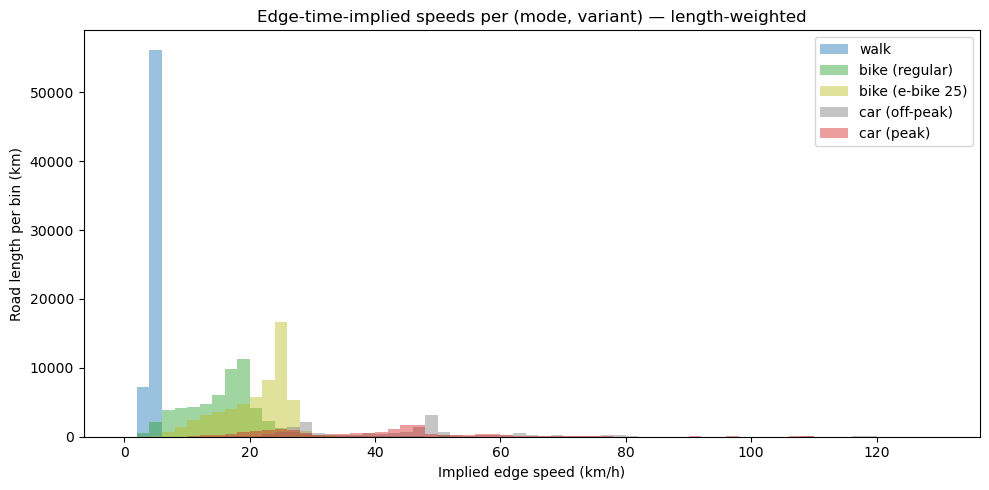

In [ ]:
# Length-weighted histogram of implied edge speeds per mode. Each edge
# contributes its length (m) to the bin, so the y-axis reads as
# "kilometres of road experiencing that implied speed". This mirrors
# what a random meter of travel would encounter — far more meaningful
# than per-edge counts (dominated by short residential links).
fig, ax = plt.subplots(figsize=(10, 5))
specs = [
    (walk_graph, 'walk_time_s',        'walk',             'tab:blue'),
    (bike_graph, 'bike_time_s',        'bike (regular)',   'tab:green'),
    (bike_graph, 'ebike_time_s',       'bike (e-bike 25)', 'tab:olive'),
    (car_graph,  'car_time_s_offpeak', 'car (off-peak)',   'tab:gray'),
    (car_graph,  'car_time_s_peak',    'car (peak)',       'tab:red'),
]
for graph, attr, label, color in specs:
    lengths, _, speeds = _edge_arrays(graph, attr)
    # Weights in km so the y-axis is intuitive.
    ax.hist(speeds, bins=np.linspace(0, 130, 66),
            weights=lengths / 1000.0,
            alpha=0.45, label=label, color=color)
ax.set_xlabel('Implied edge speed (km/h)')
ax.set_ylabel('Road length per bin (km)')
ax.set_title('Edge-time-implied speeds per (mode, variant) — length-weighted')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Eyeball check: node elevations vs DEM

Plot the DEM as a coloured background and overlay the car-graph nodes
coloured by their assigned `elevation` using the **same** colormap and
value range. If our vectorized raster lookup is right, the dots blend
seamlessly into the underlying raster; any CRS / transform misalignment
would make the dots pop out as a different colour from their neighbourhood.

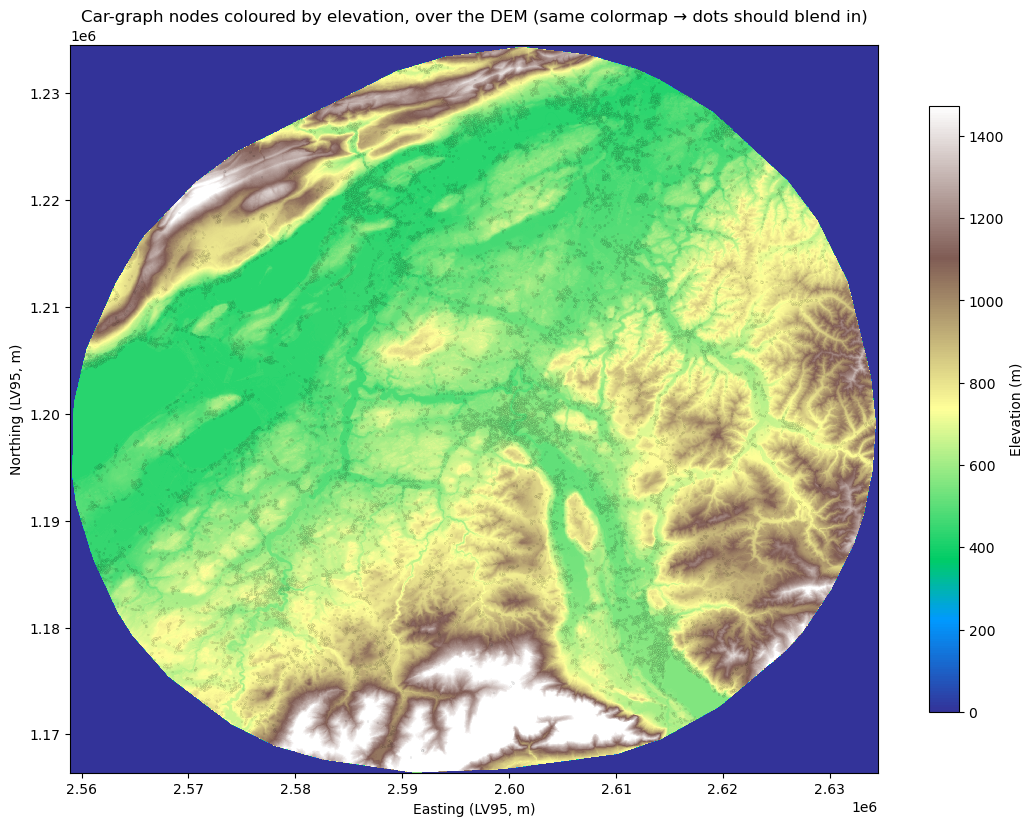

In [ ]:
with rasterio.open(DEM_PATH) as src:
    dem_arr = src.read(1).astype(float)
    dem_arr[dem_arr == src.nodata] = np.nan
    # imshow extent is (left, right, bottom, top) in CRS units.
    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

node_x = np.array([car_graph.nodes[n]['x'] for n in car_graph.nodes])
node_y = np.array([car_graph.nodes[n]['y'] for n in car_graph.nodes])
node_z = np.array([car_graph.nodes[n]['elevation'] for n in car_graph.nodes])

vmin, vmax = np.nanpercentile(dem_arr, [2, 98])
fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(dem_arr, extent=extent, origin='upper',
          cmap='terrain', vmin=vmin, vmax=vmax, interpolation='nearest')
sc = ax.scatter(node_x, node_y, c=node_z, cmap='terrain',
                vmin=vmin, vmax=vmax, s=1.5,
                edgecolors='black', linewidths=0.05)
plt.colorbar(sc, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_xlabel('Easting (LV95, m)')
ax.set_ylabel('Northing (LV95, m)')
ax.set_title('Car-graph nodes coloured by elevation, over the DEM '
             '(same colormap → dots should blend in)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

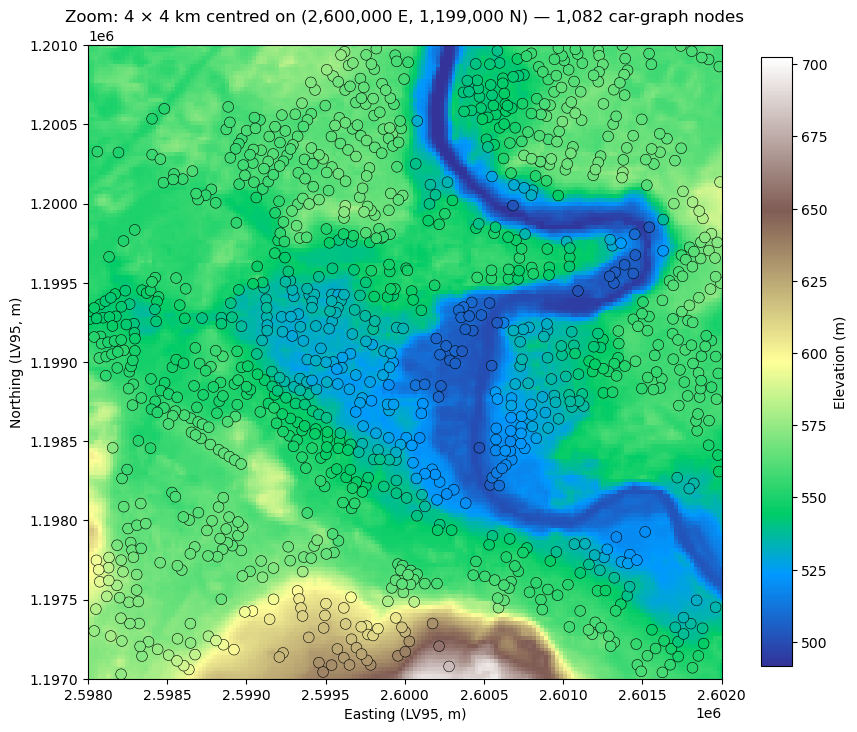

In [ ]:
# Zoomed view: 4 × 4 km tile centred on central Bern (LV95 2,600,000 E /
# 1,199,000 N). Useful for eyeballing accuracy in dense urban / steep
# micro-relief — the south of the tile catches the Gurten flank, and
# the city centre has the Aare-river meander cut ~30–40 m deep.
zoom_cx, zoom_cy = 2_600_000, 1_199_000
zoom_half = 2_000  # → 4 × 4 km

with rasterio.open(DEM_PATH) as src:
    inv = ~src.transform
    col_l, row_t = inv * (zoom_cx - zoom_half, zoom_cy + zoom_half)
    col_r, row_b = inv * (zoom_cx + zoom_half, zoom_cy - zoom_half)
    col_l, col_r = int(np.floor(col_l)), int(np.ceil(col_r))
    row_t, row_b = int(np.floor(row_t)), int(np.ceil(row_b))
    win_arr = src.read(1, window=((row_t, row_b), (col_l, col_r))).astype(float)
    win_arr[win_arr == src.nodata] = np.nan
    # imshow extent from the actual window bounds (slightly larger than
    # the requested 2 km box because we round to pixel edges).
    win_extent = (
        src.transform.a * col_l + src.transform.c,
        src.transform.a * col_r + src.transform.c,
        src.transform.e * row_b + src.transform.f,
        src.transform.e * row_t + src.transform.f,
    )

zoom_mask = (
    (node_x >= zoom_cx - zoom_half) & (node_x <= zoom_cx + zoom_half) &
    (node_y >= zoom_cy - zoom_half) & (node_y <= zoom_cy + zoom_half)
)
zx, zy, zz = node_x[zoom_mask], node_y[zoom_mask], node_z[zoom_mask]

z_vmin, z_vmax = np.nanmin(win_arr), np.nanmax(win_arr)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(win_arr, extent=win_extent, origin='upper',
          cmap='terrain', vmin=z_vmin, vmax=z_vmax, interpolation='nearest')
sc = ax.scatter(zx, zy, c=zz, cmap='terrain',
                vmin=z_vmin, vmax=z_vmax, s=60,
                edgecolors='black', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_xlim(zoom_cx - zoom_half, zoom_cx + zoom_half)
ax.set_ylim(zoom_cy - zoom_half, zoom_cy + zoom_half)
ax.set_xlabel('Easting (LV95, m)')
ax.set_ylabel('Northing (LV95, m)')
ax.set_title(f'Zoom: 4 × 4 km centred on ({zoom_cx:,} E, {zoom_cy:,} N) — '
             f'{zoom_mask.sum():,} car-graph nodes')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

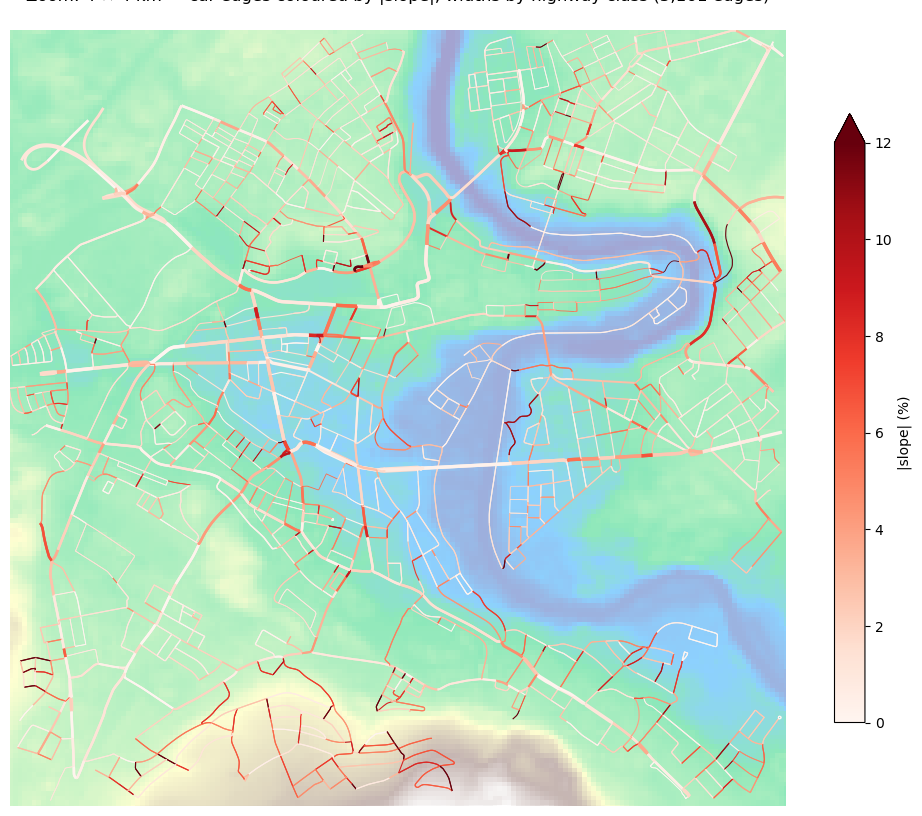

In [ ]:
# Same zoom, but with the car network overlaid: edges coloured by
# absolute slope (white → red) and width keyed to highway type. This
# is the real test of whether per-node elevation × per-edge propagation
# produced sensible slope estimates in an urban setting — flat valley
# floor near the Aare should read near-zero, while roads climbing the
# Gurten flank should saturate towards red.

# Subgraph: nodes inside the zoom box (drops border edges, fine for
# eyeballing; the full graph would also work but ox.plot_graph then
# renders 100k edges).
nodes_in_zoom = [n for n, d in car_graph.nodes(data=True)
                 if (zoom_cx - zoom_half <= float(d['x']) <= zoom_cx + zoom_half
                     and zoom_cy - zoom_half <= float(d['y']) <= zoom_cy + zoom_half)]
sub = car_graph.subgraph(nodes_in_zoom).copy()

# Per-edge: |elev_gain| + |elev_loss| = |Δz|, so absolute slope (%) =
# (gain + loss) / length × 100. (One of gain/loss is always zero.)
edge_slope_pct = np.array([
    (float(d['elev_gain']) + float(d['elev_loss'])) / float(d['length']) * 100.0
    for _, _, d in sub.edges(data=True)
])

# Edge width by highway class — coarse-grained, just enough to read
# the network hierarchy.
HWY_WIDTH = {
    'motorway': 3.5, 'motorway_link': 2.0,
    'trunk': 3.0,    'trunk_link': 1.5,
    'primary': 2.4,  'primary_link': 1.2,
    'secondary': 1.8,'secondary_link': 1.0,
    'tertiary': 1.4, 'tertiary_link': 0.9,
    'unclassified': 1.0, 'residential': 0.8,
    'living_street': 0.6, 'service': 0.5, 'road': 0.5, 'busway': 0.5,
}
def _hwy_first(h):
    return h[0] if isinstance(h, list) else h
edge_widths = np.array([
    HWY_WIDTH.get(_hwy_first(d.get('highway')), 0.5)
    for _, _, d in sub.edges(data=True)
])

# Replot: muted DEM background + roads on top. White→red cmap, cap at
# 12% slope (urban roads rarely exceed this; saturating brings out the
# Gurten flank cleanly).
slope_cap = 12.0
slope_cmap = plt.get_cmap('Reds')
edge_colors = slope_cmap(np.clip(edge_slope_pct, 0, slope_cap) / slope_cap)

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(win_arr, extent=win_extent, origin='upper',
          cmap='terrain', vmin=z_vmin, vmax=z_vmax,
          interpolation='nearest', alpha=0.45)
ox.plot_graph(sub, ax=ax, node_size=0,
              edge_color=list(edge_colors), edge_linewidth=list(edge_widths),
              bgcolor='none', show=False, close=False)
# Colorbar for slope.
sm = plt.cm.ScalarMappable(
    cmap=slope_cmap,
    norm=plt.Normalize(vmin=0, vmax=slope_cap),
)
plt.colorbar(sm, ax=ax, label='|slope| (%)', shrink=0.7, extend='max')
ax.set_xlim(zoom_cx - zoom_half, zoom_cx + zoom_half)
ax.set_ylim(zoom_cy - zoom_half, zoom_cy + zoom_half)
ax.set_xlabel('Easting (LV95, m)')
ax.set_ylabel('Northing (LV95, m)')
ax.set_title(f'Zoom: 4 × 4 km — car edges coloured by |slope|, '
             f'widths by highway class ({sub.number_of_edges():,} edges)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()